# Please run the first code (code 1) first. After seeing "All runs complete." message in the output terminal, you can run the second code (code 2) to visualize the results.

In [ ]:
# @title
# code 1 for learning and saving
ALL_SEEDS = [5, 20, 24]

ALL_MODES = ['communicating', 'independent', 'centralized']

STEPSIZE_COMPARISON_SEED = 20
RANDOM_SEED = ALL_SEEDS[0] # Set a default
import numpy as np
np.random.seed(RANDOM_SEED)
import random
random.seed(RANDOM_SEED)
import pickle
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
# Import PettingZoo and helpers for animation
try:
    import pettingzoo
    from pettingzoo.utils import parallel_to_aec, aec_to_parallel
    from pettingzoo.test import parallel_api_test
    import pygame
    from gymnasium import spaces
    from IPython.display import display, Image
    import imageio
    import os
    os.environ["SDL_VIDEODRIVER"] = "dummy"
except ImportError:
    print("Installing PettingZoo, Pygame, and imageio...")
    # The following line is for Colab/Jupyter environments
    !pip install pettingzoo[classic] pygame imageio gymnasium > /dev/null 2>&1
    import pettingzoo
    from pettingzoo.utils import parallel_to_aec, aec_to_parallel
    from pettingzoo.test import parallel_api_test
    import pygame
    from gymnasium import spaces
    from IPython.display import display, Image
    import imageio
    import os
    os.environ["SDL_VIDEODRIVER"] = "dummy"
    print("Installation complete.")
# -----------------------------
# Doubly-Stochastic Matrix Class
# -----------------------------
class NormalizedRandomMatrix:
    def __init__(self, n_rows, n_cols):
        if n_rows != n_cols:
            raise ValueError("Doubly-stochastic matrices must be square.")
        self.n_rows = n_rows
        self.n_cols = n_cols
    def generate(self, iterations=20):
        matrix = np.random.rand(self.n_rows, self.n_cols)
        for _ in range(iterations):
            col_sums = matrix.sum(axis=0, keepdims=True); col_sums[col_sums == 0] = 1; matrix = matrix / col_sums
            row_sums = matrix.sum(axis=1, keepdims=True); row_sums[row_sums == 0] = 1; matrix = matrix / row_sums
        return matrix
# -----------------------------
# Grid World Configuration & Helper Functions
# -----------------------------
NUM_AGENTS = 4
GRID_ROWS = 6
GRID_COLS = 6
NUM_CELLS = GRID_ROWS * GRID_COLS
AGENT_ACTIONS = {'UP': 0, 'DOWN': 1, 'LEFT': 2, 'RIGHT': 3, 'STAY': 4, 'RESET_RM_STAY': 5}
NUM_ACTIONS_PER_AGENT = len(AGENT_ACTIONS)
ACTION_EFFECTS = {
    AGENT_ACTIONS['UP']: (-1, 0), AGENT_ACTIONS['DOWN']: (1, 0),
    AGENT_ACTIONS['LEFT']: (0, -1), AGENT_ACTIONS['RIGHT']: (0, 1),
    AGENT_ACTIONS['STAY']: (0, 0),
    AGENT_ACTIONS['RESET_RM_STAY']: (0, 0)
}
NUM_JOINT_ACTIONS = NUM_ACTIONS_PER_AGENT ** NUM_AGENTS

SHAPING_TARGET_WEIGHT = 1.0
SHAPED_REWARD_COEFFICIENT = 0.5
def get_flat_pos(row, col): return row * GRID_COLS + col
def get_row_col(flat_pos): return flat_pos // GRID_COLS, flat_pos % GRID_COLS
# --- Global setup for start and target positions ---
START_POSITIONS_LIST = [
    21,  # Agent 1 (index 0)
    15,  # Agent 2 (index 1)
    14,  # Agent 3 (index 2)
    20,  # Agent 4 (index 3)
]
AGENT_RCH1_CELLS = {
    0: 0,   # Agent 1
    1: 30,  # Agent 2
    2: 35,  # Agent 3
    3: 5,   # Agent 4
}
AGENT_RCH2_CELLS = {
    0: 5,   # Agent 1
    1: 0,   # Agent 2
    2: 30,  # Agent 3
    3: 35,  # Agent 4
}
SAFE_TARGET_CELLS = set(AGENT_RCH1_CELLS.values()) | set(AGENT_RCH2_CELLS.values())
def get_manhattan_distance(pos1_flat, pos2_flat):
    r1, c1 = get_row_col(pos1_flat)
    r2, c2 = get_row_col(pos2_flat)
    return abs(r1 - r2) + abs(c1 - c2)
def decode_env_state(env_state_idx):
    positions = []
    temp_idx = env_state_idx
    for _ in range(NUM_AGENTS):
        positions.append(temp_idx % NUM_CELLS)
        temp_idx //= NUM_CELLS
    return positions[::-1]
def encode_env_state(positions_list):
    env_state_idx = 0
    for pos in positions_list: env_state_idx = env_state_idx * NUM_CELLS + pos
    return env_state_idx


def decode_joint_action(joint_action_idx):
    """Decodes a single index into a list of actions for each agent."""
    actions = []
    temp_idx = joint_action_idx
    for _ in range(NUM_AGENTS):
        actions.append(temp_idx % NUM_ACTIONS_PER_AGENT)
        temp_idx //= NUM_ACTIONS_PER_AGENT
    return actions[::-1]

def get_next_cell_pos(current_flat_pos, action_idx):
    r_curr, c_curr = get_row_col(current_flat_pos)
    dr, dc = ACTION_EFFECTS.get(action_idx, (0, 0))
    r_next, c_next = r_curr + dr, c_curr + dc
    if not (0 <= r_next < GRID_ROWS and 0 <= c_next < GRID_COLS):
        return current_flat_pos
    return get_flat_pos(r_next, c_next)
def get_non_colliding_initial_state():
    if len(START_POSITIONS_LIST) != NUM_AGENTS:
        raise ValueError("The number of starting positions does not match NUM_AGENTS.")
    return encode_env_state(START_POSITIONS_LIST)
# -----------------------------
# State Feature Engineering
# -----------------------------
RM_STATES = None
RM_STATE_MAP = None
NUM_RM_STATES = None

# Features for DECENTRALIZED agents ('communicating' and 'independent')
def get_state_features(env_state_idx, agent_index, rm_state):
    all_positions = decode_env_state(env_state_idx)
    my_pos = all_positions[agent_index]
    other_positions = [pos for i, pos in enumerate(all_positions) if i != agent_index]
    features = []
    my_r, my_c = get_row_col(my_pos)
    max_dist = (GRID_ROWS - 1) + (GRID_COLS - 1)
    features.extend([my_r / (GRID_ROWS - 1), my_c / (GRID_COLS - 1)])
    for pos_flat in other_positions:
        r, c = get_row_col(pos_flat)
        features.extend([r / (GRID_ROWS - 1), c / (GRID_COLS - 1)])
    dist_to_rch1 = get_manhattan_distance(my_pos, AGENT_RCH1_CELLS[agent_index])
    dist_to_rch2 = get_manhattan_distance(my_pos, AGENT_RCH2_CELLS[agent_index])
    features.append(dist_to_rch1 / max_dist if max_dist > 0 else 0)
    features.append(dist_to_rch2 / max_dist if max_dist > 0 else 0)
    for other_pos in other_positions:
        dist_to_other = get_manhattan_distance(my_pos, other_pos)
        features.append(dist_to_other / max_dist if max_dist > 0 else 0)
    is_on_edge = (my_r == 0 or my_r == GRID_ROWS - 1 or my_c == 0 or my_c == GRID_COLS - 1)
    is_in_corner = ((my_r == 0 or my_r == GRID_ROWS - 1) and (my_c == 0 or my_c == GRID_COLS - 1))
    features.extend([1.0 if is_on_edge else 0.0, 1.0 if is_in_corner else 0.0])
    rm_state_one_hot = np.zeros(NUM_RM_STATES)
    if rm_state in RM_STATE_MAP:
        rm_state_one_hot[RM_STATE_MAP[rm_state]] = 1.0
    features.extend(rm_state_one_hot)
    features.append(1.0) # Bias term
    return np.array(features)


def get_state_features_central(env_state_idx, rm_states_list):
    """Generates a feature vector for the entire system state."""
    all_positions = decode_env_state(env_state_idx)
    features = []
    max_dist = (GRID_ROWS - 1) + (GRID_COLS - 1)

    # 1. All agent positions (normalized)
    for pos_flat in all_positions:
        r, c = get_row_col(pos_flat)
        features.extend([r / (GRID_ROWS - 1), c / (GRID_COLS - 1)])

    # 2. All agent distances to their targets (rch1 and rch2)
    for i, pos_flat in enumerate(all_positions):
        dist_to_rch1 = get_manhattan_distance(pos_flat, AGENT_RCH1_CELLS[i])
        dist_to_rch2 = get_manhattan_distance(pos_flat, AGENT_RCH2_CELLS[i])
        features.append(dist_to_rch1 / max_dist if max_dist > 0 else 0)
        features.append(dist_to_rch2 / max_dist if max_dist > 0 else 0)

    # 3. Concatenated one-hot RM states for all agents
    for rm_state in rm_states_list:
        rm_state_one_hot = np.zeros(NUM_RM_STATES)
        if rm_state in RM_STATE_MAP:
            rm_state_one_hot[RM_STATE_MAP[rm_state]] = 1.0
        features.extend(rm_state_one_hot)

    # 4. Bias term
    features.append(1.0)
    return np.array(features)

def get_composite_shaped_reward(current_env_state_idx, next_env_state_idx, agent_index, current_rm_state, next_rm_state):
    current_positions = decode_env_state(current_env_state_idx)
    next_positions = decode_env_state(next_env_state_idx)
    def calculate_potential(positions, agent_idx, rm_state):
        my_pos = positions[agent_idx]
        agent_rch1_pos = AGENT_RCH1_CELLS[agent_idx]
        agent_rch2_pos = AGENT_RCH2_CELLS[agent_idx]
        if rm_state == 'q_1':
            shaping_target_pos = agent_rch2_pos
        else:
            shaping_target_pos = agent_rch1_pos
        return -SHAPING_TARGET_WEIGHT * get_manhattan_distance(my_pos, shaping_target_pos)
    potential_current = calculate_potential(current_positions, agent_index, current_rm_state)
    potential_next = calculate_potential(next_positions, agent_index, next_rm_state)
    return potential_next - potential_current


def get_composite_shaped_reward_central(current_env_state_idx, next_env_state_idx, current_rm_states, next_rm_states):
    """Calculates the sum of shaped rewards for all agents for the centralized controller."""
    total_shaped_reward = 0.0
    for i in range(NUM_AGENTS):
        total_shaped_reward += get_composite_shaped_reward(
            current_env_state_idx, next_env_state_idx, i, current_rm_states[i], next_rm_states[i]
        )
    return total_shaped_reward

# -----------------------------
# Probabilistic Action, Sampling, and Labeling
# -----------------------------
PROBABILISTIC_ACTION_CONFIG = {
    AGENT_ACTIONS['UP']: [(AGENT_ACTIONS['UP'], 0.8), (AGENT_ACTIONS['LEFT'], 0.1), (AGENT_ACTIONS['RIGHT'], 0.1)],
    AGENT_ACTIONS['DOWN']: [(AGENT_ACTIONS['DOWN'], 0.8), (AGENT_ACTIONS['LEFT'], 0.1), (AGENT_ACTIONS['RIGHT'], 0.1)],
    AGENT_ACTIONS['LEFT']: [(AGENT_ACTIONS['LEFT'], 0.8), (AGENT_ACTIONS['UP'], 0.1), (AGENT_ACTIONS['DOWN'], 0.1)],
    AGENT_ACTIONS['RIGHT']: [(AGENT_ACTIONS['RIGHT'], 0.8), (AGENT_ACTIONS['UP'], 0.1), (AGENT_ACTIONS['DOWN'], 0.1)],
    AGENT_ACTIONS['STAY']: [(AGENT_ACTIONS['STAY'], 1.0)],
    AGENT_ACTIONS['RESET_RM_STAY']: [(AGENT_ACTIONS['RESET_RM_STAY'], 1.0)]
}
def get_probabilistic_outcomes(action_idx): return PROBABILISTIC_ACTION_CONFIG.get(action_idx, [(action_idx, 1.0)])
def _calculate_next_state_with_collision_avoidance(current_s_idx, actual_actions):
    """
    Helper function to calculate the next state given a set of _actual_ (post-stochastic)
    actions, implementing the collision avoidance logic.
    """
    current_positions = decode_env_state(current_s_idx)
    # 1. Calculate all potential next positions
    potential_next_positions = [
        get_next_cell_pos(current_positions[i], actual_actions[i])
        for i in range(NUM_AGENTS)
    ]
    # 2. Check for collisions
    final_positions = list(current_positions)
    agent_indices = list(range(NUM_AGENTS))
    colliding_agents = set()
    for i in agent_indices:
        if i in colliding_agents: continue
        for j in range(i + 1, NUM_AGENTS):
            if j in colliding_agents: continue
            # Check 1: Destination Collision
            # (Agents moving to the same cell)
            if potential_next_positions[i] == potential_next_positions[j]:
                destination_cell = potential_next_positions[i]
                if destination_cell not in SAFE_TARGET_CELLS:
                    colliding_agents.add(i)
                    colliding_agents.add(j)
    for i in agent_indices:
        if i not in colliding_agents:
            final_positions[i] = potential_next_positions[i]
        # Else: final_positions[i] remains current_positions[i] (STAY)
    return encode_env_state(final_positions)
def sample_next_state(current_s_idx, joint_action_indices):
    actual_actions = []
    for i in range(NUM_AGENTS):
        outcomes = get_probabilistic_outcomes(joint_action_indices[i])
        actions, probs = zip(*outcomes)
        actual_actions.append(np.random.choice(actions, p=probs))
    # 2. Calculate next state using the new helper function
    return _calculate_next_state_with_collision_avoidance(current_s_idx, actual_actions)
def get_label(env_state_idx, agent_index):
    positions = decode_env_state(env_state_idx)
    is_rch1 = (positions[agent_index] == AGENT_RCH1_CELLS[agent_index])
    is_rch2 = (positions[agent_index] == AGENT_RCH2_CELLS[agent_index])
    rch1_str = "(rch1)" if is_rch1 else "(!rch1)"
    rch2_str = "(rch2)" if is_rch2 else "(!rch2)"
    return f"{rch1_str}&{rch2_str}"
# -----------------------------
# Reward Machine & RL Components
# -----------------------------
class RewardMachine:
    def __init__(self, initial_state, states, transitions):
        self.initial_state = initial_state
        self.states = states
        self.transitions = {key: (value[0][0], int(value[0][1])) for key, value in transitions.items()}
    def step(self, current_rm_state, symbol):
        return self.transitions.get((current_rm_state, symbol), (current_rm_state, 0.0))
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)
# -----------------------------
# PettingZoo Environment
# -----------------------------
class GridWorldEnv(pettingzoo.ParallelEnv):
    metadata = {"render_modes": ["rgb_array"], "name": "gridworld-v0"}
    def __init__(self, render_mode="rgb_array"):
        self.agents = [f"agent_{i+1}" for i in range(NUM_AGENTS)]
        self.possible_agents = self.agents[:]; self.render_mode = render_mode
        self.num_env_states = NUM_CELLS ** NUM_AGENTS; self.current_env_state = 0
        self.observation_space = {a: spaces.Discrete(self.num_env_states) for a in self.agents}
        self.action_space = {a: spaces.Discrete(NUM_ACTIONS_PER_AGENT) for a in self.agents}
        self.screen_width, self.screen_height, self.screen = 400, 400, None
        colors = [plt.cm.viridis(i/max(1, NUM_AGENTS-1)) for i in range(NUM_AGENTS)]
        self.agent_colors = [(int(r*255), int(g*255), int(b*255)) for r,g,b,a in colors]
    def reset(self, seed=None, options=None):
        if seed is not None: np.random.seed(seed); random.seed(seed)
        self.current_env_state = get_non_colliding_initial_state()
        return self._get_obs(), {a: {} for a in self.agents}
    def _get_obs(self): return {a: self.current_env_state for a in self.agents}
    # --- MODIFIED FUNCTION ---
    def step(self, actions):
        actual_actions = []
        for i, agent_id in enumerate(self.agents):
            policy_action = actions[agent_id]
            outcomes = get_probabilistic_outcomes(policy_action)
            action_choices, probs = zip(*outcomes)
            actual_actions.append(np.random.choice(action_choices, p=probs))
        self.current_env_state = _calculate_next_state_with_collision_avoidance(
            self.current_env_state,
            actual_actions
        )
        return self._get_obs(),{a:0 for a in self.agents},{a:False for a in self.agents},{a:False for a in self.agents},{a:{} for a in self.agents}
    def render(self):
        if self.screen is None: pygame.init(); self.screen = pygame.Surface((self.screen_width, self.screen_height))
        cell_w, cell_h = self.screen_width/GRID_COLS, self.screen_height/GRID_ROWS
        self.screen.fill((255, 255, 255))
        indicator_w = cell_w / 2
        indicator_h = cell_h / 2
        # Define the (x, y) offset for each agent's quadrant within a cell
        # Agent 0: top-left, 1: top-right, 2: bottom-left, 3: bottom-right
        quadrant_offsets = [
            (0, 0),
            (indicator_w, 0),
            (0, indicator_h),
            (indicator_w, indicator_h)
        ]
        for i in range(NUM_AGENTS):
            agent_color = self.agent_colors[i]
            offset_x, offset_y = quadrant_offsets[i]
            rch1_flat = AGENT_RCH1_CELLS[i]
            r1, c1 = get_row_col(rch1_flat)
            rch1_color = (min(255, agent_color[0] + 120),
                          min(255, agent_color[1] + 120),
                          min(255, agent_color[2] + 120))
            indicator_x1 = c1 * cell_w + offset_x
            indicator_y1 = r1 * cell_h + offset_y
            pygame.draw.rect(self.screen, rch1_color, (indicator_x1, indicator_y1, indicator_w, indicator_h))
            rch2_flat = AGENT_RCH2_CELLS[i]
            r2, c2 = get_row_col(rch2_flat)
            rch2_color = agent_color
            indicator_x2 = c2 * cell_w + offset_x
            indicator_y2 = r2 * cell_h + offset_y
            pygame.draw.rect(self.screen, rch2_color, (indicator_x2, indicator_y2, indicator_w, indicator_h))
        for r in range(GRID_ROWS):
            for c in range(GRID_COLS): pygame.draw.rect(self.screen, (128,128,128), (c*cell_w, r*cell_h, cell_w, cell_h), 1)
        for i, pos_flat in enumerate(decode_env_state(self.current_env_state)):
            r,c = get_row_col(pos_flat)
            pygame.draw.circle(self.screen, self.agent_colors[i], (c*cell_w+cell_w/2, r*cell_h+cell_h/2), min(cell_w, cell_h)/3)
        if self.render_mode == "rgb_array": return np.transpose(np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2))
    def close(self):
        if self.screen: pygame.quit(); self.screen = None
# -----------------------------
# Main Training Loop (Modified)
# -----------------------------

def run_experiment(mode, seed_index, total_training_steps = 80000):
    """
    Runs a full training and evaluation experiment.
    Args:
        mode (str): 'communicating', 'independent', or 'centralized'.
        seed_index (int): The 1-based ordered index of the seed (e.g., 1, 2, 3...).
        total_training_steps (int): Number of steps for training.
    """
    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    global RM_STATES, RM_STATE_MAP, NUM_RM_STATES
    if mode not in ['communicating', 'independent', 'centralized']:
        raise ValueError("Mode must be 'communicating', 'independent', or 'centralized'")

    # --- General Hyperparameters ---
    num_agents = NUM_AGENTS
    penalty = -2
    alpha_exponent_critic, alpha_exponent_actor = 0.70, 0.85
    initial_entropy_coeff = 0.15
    final_entropy_coeff = 0.0001
    annealing_steps = int(total_training_steps * 0.9)

    # --- Reward Machine Definition ---
    rm = RewardMachine('q_0', {'q_0','q_1'}, {
        ('q_0',"(rch1)&(rch2)"): [('q_0',True)],
        ('q_0',"(!rch1)&(rch2)"): [('q_0',False)],
        ('q_0',"(rch1)&(!rch2)"): [('q_1',False)],
        ('q_0',"(!rch1)&(!rch2)"): [('q_0',False)],
        ('q_1',"(rch1)&(rch2)"): [('q_0',True)],
        ('q_1',"(!rch1)&(rch2)"): [('q_0',True)],
        ('q_1',"(rch1)&(!rch2)"): [('q_1',False)],
        ('q_1',"(!rch1)&(!rch2)"): [('q_1',False)],
    })
    RM_STATES = sorted(list(rm.states))
    RM_STATE_MAP = {state: i for i, state in enumerate(RM_STATES)}
    NUM_RM_STATES = len(RM_STATES)

    # --- History Tracking Initialization ---
    steps_history, overall_average_reward_history = [], []
    policy_tracking_state_idx = 100
    policy_history_at_specific_state = [[] for _ in range(num_agents)] # Note: only used in decentralized
    policy_sampling_steps = []; sample_interval = 20000
    count_successful_satisfactions_total = 0
    successful_satisfactions_history = []

    count_reset_actions_total = 0
    reset_action_counts_history = []
    # ---
    training_frames = []
    render_interval = 500
    render_env = GridWorldEnv()
    current_env_state = get_non_colliding_initial_state()

    # ==============================================================================
    # >>>>>>>>>>>>>>>>>>>>>>>>> CENTRALIZED LEARNING SCENARIO <<<<<<<<<<<<<<<<<<<<<<
    # ==============================================================================
    if mode == 'centralized':
        # Define feature vector size for centralized agent
        num_features_central = 2 * num_agents + 2 * num_agents + NUM_RM_STATES * num_agents + 1
        actor_weights = np.random.randn(num_features_central, NUM_JOINT_ACTIONS) * 0.1
        critic_weights = np.zeros(num_features_central)
        rho = 0.0 # Single average reward
        rm_states = [rm.initial_state for _ in range(num_agents)]
        cumulative_reward = 0.0 # Single cumulative reward

        for step in range(total_training_steps):
            t = step + 1.0
            alpha_critic, alpha_actor = 1.0/(t**alpha_exponent_critic), 1.0/(t**alpha_exponent_actor)
            current_entropy_coeff = initial_entropy_coeff - (initial_entropy_coeff - final_entropy_coeff) * (step / annealing_steps) if step < annealing_steps else final_entropy_coeff

            # Get centralized features
            features = get_state_features_central(current_env_state, rm_states)
            logits = np.dot(features, actor_weights)
            probs = softmax(logits)
            joint_action_chosen_idx = np.random.choice(NUM_JOINT_ACTIONS, p=probs)
            actions_chosen = decode_joint_action(joint_action_chosen_idx)

            # --- Count reset actions ---
            reset_count_this_step = actions_chosen.count(AGENT_ACTIONS['RESET_RM_STAY'])
            count_reset_actions_total += reset_count_this_step
            reset_action_counts_history.append(count_reset_actions_total)
            # ---

            next_env_state = sample_next_state(current_env_state, actions_chosen)
            labels = [get_label(next_env_state, i) for i in range(num_agents)]

            rm_rewards = [0.0] * num_agents
            next_rm_states = [None] * num_agents
            for i in range(num_agents):
                if actions_chosen[i] == AGENT_ACTIONS['RESET_RM_STAY']:
                    next_rm_states[i], rm_rewards[i] = rm.initial_state, penalty
                else:
                    next_rm, r = rm.step(rm_states[i], labels[i])
                    if r > 0:
                        count_successful_satisfactions_total += 1
                    next_rm_states[i], rm_rewards[i] = next_rm, float(r)

            global_reward = sum(rm_rewards)
            current_features = get_state_features_central(current_env_state, rm_states)
            next_features = get_state_features_central(next_env_state, next_rm_states)

            v_curr = np.dot(current_features, critic_weights)
            v_next = np.dot(next_features, critic_weights)
            delta_critic = global_reward - rho + v_next - v_curr
            critic_weights += alpha_critic * delta_critic * current_features
            rho += alpha_critic * delta_critic

            shaped_reward_val = get_composite_shaped_reward_central(current_env_state, next_env_state, rm_states, next_rm_states)
            entropy = -np.sum(probs * np.log(probs + 1e-8))
            delta_actor = delta_critic + SHAPED_REWARD_COEFFICIENT * shaped_reward_val + current_entropy_coeff * entropy

            grad_log_policy = -np.outer(current_features, probs)
            grad_log_policy[:, joint_action_chosen_idx] += current_features
            actor_weights += alpha_actor * delta_actor * grad_log_policy

            current_env_state, rm_states = next_env_state, next_rm_states
            steps_history.append(step)
            cumulative_reward += global_reward
            overall_average_reward_history.append(cumulative_reward / (step + 1))
            successful_satisfactions_history.append(count_successful_satisfactions_total)

            if step % render_interval == 0:
                render_env.current_env_state = current_env_state
                training_frames.append(render_env.render())


        rhos = [rho]


    # ==============================================================================
    # >>>>>>>>>>>>>>>>>> DECENTRALIZED (COMMUNICATING / INDEPENDENT) <<<<<<<<<<<<<<<
    # ==============================================================================
    else: # Handles 'communicating' and 'independent' modes
        num_base_features = 2 + (num_agents - 1) * 2 + 2 + (num_agents - 1) + 2
        num_features = num_base_features + NUM_RM_STATES + 1

        # Define communication matrix W
        W = np.full((num_agents, num_agents), 1 / num_agents)

        actor_weights = [np.random.randn(num_features, NUM_ACTIONS_PER_AGENT) * 0.1 for _ in range(num_agents)]
        critic_weights = [np.zeros(num_features) for _ in range(num_agents)]
        rhos = [0.0 for _ in range(num_agents)]
        rm_states = [rm.initial_state for _ in range(num_agents)]
        cumulative_rewards = [0 for _ in range(num_agents)]

        for step in range(total_training_steps):
            t = step + 1.0
            alpha_critic, alpha_actor = 1.0/(t**alpha_exponent_critic), 1.0/(t**alpha_exponent_actor)
            current_entropy_coeff = initial_entropy_coeff - (initial_entropy_coeff - final_entropy_coeff) * (step / annealing_steps) if step < annealing_steps else final_entropy_coeff

            actions_chosen, action_probs = [], []
            for i in range(num_agents):
                features = get_state_features(current_env_state, i, rm_states[i])
                logits = np.dot(features, actor_weights[i])
                probs = softmax(logits)
                action_probs.append(probs)
                actions_chosen.append(np.random.choice(NUM_ACTIONS_PER_AGENT, p=probs))


            reset_count_this_step = actions_chosen.count(AGENT_ACTIONS['RESET_RM_STAY'])
            count_reset_actions_total += reset_count_this_step
            reset_action_counts_history.append(count_reset_actions_total)


            next_env_state = sample_next_state(current_env_state, actions_chosen)
            labels = [get_label(next_env_state, i) for i in range(num_agents)]

            rm_rewards = [0.0] * num_agents
            next_rm_states = [None] * num_agents
            for i in range(num_agents):
                if actions_chosen[i] == AGENT_ACTIONS['RESET_RM_STAY']:
                    next_rm_states[i], rm_rewards[i] = rm.initial_state, penalty
                else:
                    next_rm, r = rm.step(rm_states[i], labels[i])
                    if r > 0:
                        count_successful_satisfactions_total += 1
                    next_rm_states[i], rm_rewards[i] = next_rm, float(r)

            for i in range(num_agents):
                current_features = get_state_features(current_env_state, i, rm_states[i])
                next_features = get_state_features(next_env_state, i, next_rm_states[i])
                v_curr = np.dot(current_features, critic_weights[i])
                v_next = np.dot(next_features, critic_weights[i])
                delta_critic = rm_rewards[i] - rhos[i] + v_next - v_curr
                critic_weights[i] += alpha_critic * delta_critic * current_features
                rhos[i] += alpha_critic * delta_critic

                shaped_reward_val = get_composite_shaped_reward(
                    current_env_state, next_env_state, i, rm_states[i], next_rm_states[i]
                )

                probs = action_probs[i]
                entropy = -np.sum(probs * np.log(probs + 1e-8))
                delta_actor = delta_critic + SHAPED_REWARD_COEFFICIENT * shaped_reward_val + current_entropy_coeff * entropy

                grad_log_policy = -np.outer(current_features, action_probs[i])
                grad_log_policy[:, actions_chosen[i]] += current_features
                actor_weights[i] += alpha_actor * delta_actor * grad_log_policy


            if mode == 'communicating':
                critic_weights = [sum(W[i, j] * c for j, c in enumerate(critic_weights)) for i in range(num_agents)]
                rhos = [sum(W[i, j] * r for j, r in enumerate(rhos)) for i in range(num_agents)]



            current_env_state, rm_states = next_env_state, next_rm_states

            steps_history.append(step)
            for i in range(num_agents): cumulative_rewards[i] += rm_rewards[i]
            overall_average_reward_history.append(np.mean([cr / (step + 1) for cr in cumulative_rewards]))

            if step > 0 and (step % sample_interval == 0 or step == total_training_steps - 1):
                if policy_tracking_state_idx < NUM_CELLS ** NUM_AGENTS:
                    policy_sampling_steps.append(step)
                    for i in range(num_agents):
                        features = get_state_features(policy_tracking_state_idx, i, 'q_0')
                        policy_history_at_specific_state[i].append(softmax(np.dot(features, actor_weights[i])))

            successful_satisfactions_history.append(count_successful_satisfactions_total)
            if step % render_interval == 0:
                render_env.current_env_state = current_env_state
                training_frames.append(render_env.render())

    # --- END OF TRAINING (All modes) ---
    render_env.close()

    if training_frames:

        gif_filename = f'training_animation_{mode}_seed_{seed_index}.gif'
        print(f"\n--- Saving training animation to '{gif_filename}' ---")
        imageio.mimsave(gif_filename, training_frames, fps=20)

    # <<< --- START OF MODIFIED SAVE BLOCK --- >>>
    print("\n--- Saving Final Results ---")


    save_file_npz = f'training_results_{mode}_seed_{RANDOM_SEED}.npz'
    save_file_pkl = f'reward_machine_{mode}_seed_{RANDOM_SEED}.pkl'

    try:
        # 1. Save all numerical/list data using numpy
        np.savez_compressed(
            save_file_npz,
            actor_weights=actor_weights,
            critic_weights=critic_weights,
            rhos=rhos,
            steps_history=steps_history,
            overall_average_reward_history=overall_average_reward_history,
            successful_satisfactions_history=successful_satisfactions_history,
            reset_action_counts_history=reset_action_counts_history,
            policy_tracking_state_idx=policy_tracking_state_idx,
            policy_sampling_steps=policy_sampling_steps,
            policy_history_at_specific_state=np.array(policy_history_at_specific_state, dtype=object),
            training_frames=training_frames
        )

        # 2. Save the RewardMachine object using pickle
        with open(save_file_pkl, 'wb') as f: # Use modified filename
            pickle.dump(rm, f)


        print(f"Successfully saved 'training_results_{mode}_seed_{seed_index}.npz' and 'reward_machine_{mode}_seed_{seed_index}.pkl'.")
        print("You can now run the visualization cell to re-generate plots and evaluations.")

    except Exception as e:
        print(f"Error saving results: {e}")



    # ==============================================================================
    # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>> EVALUATION SECTION <<<<<<<<<<<<<<<<<<<<<<<<<<<<
    # ==============================================================================
    print(f"\nStarting final evaluation... (Mode: {mode.capitalize()}, SEED {seed_index})")
    num_evaluation_steps = 10000; env = GridWorldEnv()

    # --- MODIFICATION: Use the run's seed + 1 for evaluation reproducibility ---
    obs, _ = env.reset(seed=RANDOM_SEED + 1)

    evaluation_frames = []
    num_eval_animation_steps = 1000
    eval_satisfactions = 0
    eval_steps_history, eval_satisfactions_history = [], []
    evaluation_temperature = 0.9

    # --- Centralized Evaluation ---
    if mode == 'centralized':
        eval_rm_states = [rm.initial_state for _ in range(num_agents)]
        for step in range(num_evaluation_steps):
            if step < num_eval_animation_steps:
                evaluation_frames.append(env.render())

            current_s_idx = obs["agent_1"]
            features = get_state_features_central(current_s_idx, eval_rm_states)
            logits = np.dot(features, actor_weights) # actor_weights is single array
            temp_adjusted_logits = logits / evaluation_temperature
            action_probabilities = softmax(temp_adjusted_logits)
            joint_action_idx = np.random.choice(NUM_JOINT_ACTIONS, p=action_probabilities)
            actions_list = decode_joint_action(joint_action_idx)
            actions_dict = {f"agent_{i+1}": actions_list[i] for i in range(num_agents)}

            obs, _, _, _, _ = env.step(actions_dict) # env.step uses the collision-aware logic
            next_s_idx = obs["agent_1"]
            labels = [get_label(next_s_idx, i) for i in range(num_agents)]
            temp_next_rm_states = list(eval_rm_states)

            for i in range(num_agents):
                if actions_dict[f"agent_{i+1}"] == AGENT_ACTIONS['RESET_RM_STAY']:
                    temp_next_rm_states[i] = rm.initial_state
                else:
                    next_rm, r = rm.step(eval_rm_states[i], labels[i])
                    temp_next_rm_states[i] = next_rm
                    if r > 0:
                        eval_satisfactions += 1
            eval_rm_states = temp_next_rm_states
            eval_steps_history.append(step); eval_satisfactions_history.append(eval_satisfactions)

    # --- Decentralized Evaluation ---
    else: # 'communicating' or 'independent'
        eval_rm_states = [rm.initial_state for _ in range(num_agents)]
        for step in range(num_evaluation_steps):
            if step < num_eval_animation_steps:
                evaluation_frames.append(env.render())

            actions_dict = {}
            current_s_idx = obs["agent_1"]
            for i in range(num_agents):
                agent_id_str = f"agent_{i+1}"
                features = get_state_features(current_s_idx, i, eval_rm_states[i])
                logits = np.dot(features, actor_weights[i])
                temp_adjusted_logits = logits / evaluation_temperature
                action_probabilities = softmax(temp_adjusted_logits)
                actions_dict[agent_id_str] = np.random.choice(NUM_ACTIONS_PER_AGENT, p=action_probabilities)

            obs, _, _, _, _ = env.step(actions_dict)
            next_s_idx = obs["agent_1"]
            labels = [get_label(next_s_idx, i) for i in range(num_agents)]
            temp_next_rm_states = list(eval_rm_states)

            for i in range(num_agents):
                agent_id_str = f"agent_{i+1}"
                if actions_dict[agent_id_str] == AGENT_ACTIONS['RESET_RM_STAY']:
                    temp_next_rm_states[i] = rm.initial_state
                else:
                    next_rm, r = rm.step(eval_rm_states[i], labels[i])
                    temp_next_rm_states[i] = next_rm
                    if r > 0:
                        eval_satisfactions += 1
            eval_rm_states = temp_next_rm_states
            eval_steps_history.append(step); eval_satisfactions_history.append(eval_satisfactions)

    # --- END OF EVALUATION (All modes) ---
    env.close()

    if evaluation_frames:
        # --- MODIFICATION: Use mode and seed_index for animation filenames ---
        gif_filename = f'trained_agent_animation_{mode}_seed_{seed_index}.gif'
        print(f"\n--- Saving trained agent animation to '{gif_filename}' ---")
        imageio.mimsave(gif_filename, evaluation_frames, fps=30)

    print("\n--- Final Evaluation Results ---")
    print(f"Total Successful Satisfactions: {eval_satisfactions}")

    # --- Plotting Section (for this specific run) ---
    print(f"\n--- Generating Plots (Mode: {mode.capitalize()}, SEED {seed_index}) ---")
    plt.style.use('seaborn-v0_8-whitegrid')

    plt.figure(figsize=(10, 6))
    plt.plot(eval_steps_history, eval_satisfactions_history, label='Cumulative Satisfactions (Eval)', color='green', linewidth=2)

    plt.title(f"Trained Agent Performance - {mode.capitalize()} (SEED {seed_index})", fontsize=16)
    plt.xlabel("Evaluation Steps", fontsize=12); plt.ylabel("Cumulative Counts", fontsize=12)
    plt.legend(fontsize=10); plt.tight_layout();

    plt.savefig(f"plot_evaluation_performance_{mode}_seed_{RANDOM_SEED}.png"); plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(steps_history, overall_average_reward_history, label='Avg. Cumulative Reward', color='purple', linewidth=2)

    plt.title(f"Average Reward During Training - {mode.capitalize()} (SEED {seed_index})", fontsize=16)
    plt.xlabel("Training Steps", fontsize=12); plt.ylabel("Average Reward", fontsize=12)
    plt.legend(fontsize=10); plt.tight_layout();

    plt.savefig(f"plot_training_reward_{mode}_seed_{RANDOM_SEED}.png"); plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(steps_history, successful_satisfactions_history, label='Cumulative Satisfactions', color='green', linewidth=2)

    plt.title(f"Task Monitoring During Training - {mode.capitalize()} (SEED {seed_index})", fontsize=16)
    plt.xlabel("Training Steps", fontsize=12); plt.ylabel("Cumulative Counts", fontsize=12)
    plt.legend(fontsize=10); plt.tight_layout();

    plt.savefig(f"plot_training_satisfactions_{mode}_seed_{RANDOM_SEED}.png"); plt.close()

    # Policy plots only make sense for decentralized agents
    if mode != 'centralized' and policy_tracking_state_idx < NUM_CELLS ** NUM_AGENTS:
        action_labels, colors = list(AGENT_ACTIONS.keys()), plt.cm.viridis(np.linspace(0,1,NUM_ACTIONS_PER_AGENT))
        for i in range(num_agents):
            plt.figure(figsize=(12, 7))
            if policy_history_at_specific_state[i]:
                policy_hist = np.array(policy_history_at_specific_state[i]).T
                for action_idx, action_prob_evo in enumerate(policy_hist):
                    plt.plot(policy_sampling_steps, action_prob_evo, label=f'{action_labels[action_idx]}', color=colors[action_idx], linewidth=2)

            plt.title(f"Agent {i+1}: Policy Evolution (State {policy_tracking_state_idx}, RM 'q_0') - {mode.capitalize()} (SEED {seed_index})", fontsize=16)
            plt.xlabel("Training Steps", fontsize=12); plt.ylabel("Action Probability", fontsize=12)
            plt.legend(fontsize=10, loc='best'); plt.ylim(0, 1.05); plt.tight_layout();

            plt.savefig(f"plot_policy_evolution_agent_{i+1}_{mode}_seed_{RANDOM_SEED}.png"); plt.close()


# ---------------------------------------------
# --- NEW: STEPSIZE COMPARISON FUNCTION ---
# ---------------------------------------------
def run_stepsize_comparison(total_training_steps = 80000):
    """
    Runs a special experiment just for comparing stepsizes.
    This runs ONLY for the 'communicating' mode and for the
    globally set RANDOM_SEED (which should be set to STEPSIZE_COMPARISON_SEED).
    """
    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    global RM_STATES, RM_STATE_MAP, NUM_RM_STATES
    num_agents = NUM_AGENTS
    penalty = -2
    alpha_exponent_critic, alpha_exponent_actor = 0.70, 0.85
    initial_entropy_coeff = 0.15
    final_entropy_coeff = 0.0001
    annealing_steps = int(total_training_steps * 0.9)

    # --- Reward Machine Definition ---
    rm = RewardMachine('q_0', {'q_0','q_1'}, {
        ('q_0',"(rch1)&(rch2)"): [('q_0',True)],
        ('q_0',"(!rch1)&(rch2)"): [('q_0',False)],
        ('q_0',"(rch1)&(!rch2)"): [('q_1',False)],
        ('q_0',"(!rch1)&(!rch2)"): [('q_0',False)],
        ('q_1',"(rch1)&(rch2)"): [('q_0',True)],
        ('q_1',"(!rch1)&(rch2)"): [('q_0',True)],
        ('q_1',"(rch1)&(!rch2)"): [('q_1',False)],
        ('q_1',"(!rch1)&(!rch2)"): [('q_1',False)],
    })
    RM_STATES = sorted(list(rm.states))
    RM_STATE_MAP = {state: i for i, state in enumerate(RM_STATES)}
    NUM_RM_STATES = len(RM_STATES)

    # --- Feature definition (decentralized only) ---
    num_base_features = 2 + (num_agents - 1) * 2 + 2 + (num_agents - 1) + 2
    num_features = num_base_features + NUM_RM_STATES + 1
    W = np.full((num_agents, num_agents), 1 / num_agents)

    # --- Define the different stepsize configurations to test ---
    stepsize_configs = {
        "Variable (num=1, original)": {'type': 'variable', 'numerator': 1.0},
        "Variable (num=0.1)": {'type': 'variable', 'numerator': 0.1},
        "Variable (num=5)": {'type': 'variable', 'numerator': 5.0},
        "Constant (critic=0.01, actor=0.005)": {'type': 'constant', 'critic': 0.01, 'actor': 0.005},
        "Constant (critic=0.001, actor=0.0005)": {'type': 'constant', 'critic': 0.001, 'actor': 0.0005},
    }

    all_reward_histories = {} # Dictionary to store results

    # --- Outer loop to iterate through each configuration ---
    for name, config in stepsize_configs.items():
        print(f"\n--- Starting Training for Stepsize Config: {name} (SEED {RANDOM_SEED}) ---")

        # --- Reset everything for a fair run ---
        np.random.seed(RANDOM_SEED)
        random.seed(RANDOM_SEED)

        actor_weights = [np.random.randn(num_features, NUM_ACTIONS_PER_AGENT) * 0.1 for _ in range(num_agents)]
        critic_weights = [np.zeros(num_features) for _ in range(num_agents)]
        rhos = [0.0 for _ in range(num_agents)]

        steps_history, overall_average_reward_history = [], []
        cumulative_rewards = [0 for _ in range(num_agents)]
        rm_states = [rm.initial_state for _ in range(num_agents)]
        current_env_state = get_non_colliding_initial_state()

        # (Histories for satisfactions, resets, policy, etc. are not needed for this plot)

        # --- Main training loop (now inside the config loop) ---
        for step in range(total_training_steps):
            t = step + 1.0


            if config['type'] == 'variable':
                numerator = config['numerator']
                alpha_critic = numerator / (t ** alpha_exponent_critic)
                alpha_actor = numerator / (t ** alpha_exponent_actor)
            elif config['type'] == 'constant':
                alpha_critic = config['critic']
                alpha_actor = config['actor']
            # --- END KEY CHANGE ---

            if step < annealing_steps:
                current_entropy_coeff = initial_entropy_coeff - (initial_entropy_coeff - final_entropy_coeff) * (step / annealing_steps)
            else:
                current_entropy_coeff = final_entropy_coeff

            actions_chosen, action_probs = [], []
            for i in range(num_agents):
                features = get_state_features(current_env_state, i, rm_states[i])
                logits = np.dot(features, actor_weights[i])
                probs = softmax(logits)
                action_probs.append(probs)
                actions_chosen.append(np.random.choice(NUM_ACTIONS_PER_AGENT, p=probs))

            next_env_state = sample_next_state(current_env_state, actions_chosen)
            labels = [get_label(next_env_state, i) for i in range(num_agents)]

            rm_rewards = [0.0] * num_agents
            next_rm_states = [None] * num_agents
            for i in range(num_agents):
                if actions_chosen[i] == AGENT_ACTIONS['RESET_RM_STAY']:
                    next_rm_states[i], rm_rewards[i] = rm.initial_state, penalty
                else:
                    next_rm, r = rm.step(rm_states[i], labels[i])

                    next_rm_states[i], rm_rewards[i] = next_rm, float(r)

            for i in range(num_agents):
                current_features = get_state_features(current_env_state, i, rm_states[i])
                next_features = get_state_features(next_env_state, i, next_rm_states[i])
                v_curr = np.dot(current_features, critic_weights[i])
                v_next = np.dot(next_features, critic_weights[i])
                delta_critic = rm_rewards[i] - rhos[i] + v_next - v_curr
                critic_weights[i] += alpha_critic * delta_critic * current_features
                rhos[i] += alpha_critic * delta_critic

                shaped_reward_val = get_composite_shaped_reward(
                    current_env_state, next_env_state, i, rm_states[i], next_rm_states[i]
                )

                probs = action_probs[i]
                entropy = -np.sum(probs * np.log(probs + 1e-8))
                delta_actor = delta_critic + SHAPED_REWARD_COEFFICIENT * shaped_reward_val + current_entropy_coeff * entropy

                grad_log_policy = -np.outer(current_features, action_probs[i])
                grad_log_policy[:, actions_chosen[i]] += current_features
                actor_weights[i] += alpha_actor * delta_actor * grad_log_policy

            # --- This is the 'communicating' logic ---
            critic_weights = [sum(W[i, j] * c for j, c in enumerate(critic_weights)) for i in range(num_agents)]
            rhos = [sum(W[i, j] * r for j, r in enumerate(rhos)) for i in range(num_agents)]

            current_env_state, rm_states = next_env_state, next_rm_states
            steps_history.append(step)
            for i in range(num_agents): cumulative_rewards[i] += rm_rewards[i]
            overall_average_reward_history.append(np.mean([cr / (step + 1) for cr in cumulative_rewards]))


        # --- Store results for this configuration ---
        # Save as a tuple (steps, rewards)
        all_reward_histories[name] = (steps_history, overall_average_reward_history)
        print(f"--- Finished Training for {name}. ---")

    # --- Save the final results dictionary ---
    save_file_npz = f'stepsize_comparison_results_seed_{RANDOM_SEED}.npz'
    try:
        np.savez_compressed(save_file_npz, **all_reward_histories)
        print(f"\n--- Successfully saved stepsize comparison to '{save_file_npz}' ---")
    except Exception as e:
        print(f"Error saving stepsize results: {e}")


if __name__ == "__main__":

    for mode in ALL_MODES:
        for i, seed in enumerate(ALL_SEEDS):

            print(f"\n\n{'='*20} STARTING RUN: MODE={mode.upper()}, SEED={i+1} {'='*20}\n")
            # Set the global seed variable, which run_experiment() will use
            RANDOM_SEED = seed
            # Call the main training function, passing mode and seed_index
            run_experiment(mode=mode, seed_index=i + 1)

            print(f"\n{'='*20} COMPLETED RUN: MODE={mode.upper()}, SEED={i+1} {'='*20}\n")


    if STEPSIZE_COMPARISON_SEED in ALL_SEEDS:
        print(f"\n\n{'='*20} STARTING STEPSIZE COMPARISON (SEED {STEPSIZE_COMPARISON_SEED}) {'='*20}\n")
        RANDOM_SEED = STEPSIZE_COMPARISON_SEED
        run_stepsize_comparison()
        print(f"\n{'='*20} COMPLETED STEPSIZE COMPARISON (SEED {STEPSIZE_COMPARISON_SEED}) {'='*20}\n")
    else:
        print(f"\n--- Skipping stepsize comparison: SEED {STEPSIZE_COMPARISON_SEED} not in ALL_SEEDS ---")

    print("\n\nAll runs complete.")

Installing PettingZoo, Pygame, and imageio...
Installation complete.


==================== STARTING RUN: MODE=COMMUNICATING, SEED=1 ====================


--- Saving training animation to 'training_animation_communicating_seed_1.gif' ---

--- Saving Final Results ---
Successfully saved 'training_results_communicating_seed_1.npz' and 'reward_machine_communicating_seed_1.pkl'.
You can now run the visualization cell to re-generate plots and evaluations.

Starting final evaluation... (Mode: Communicating, SEED 1)

--- Saving trained agent animation to 'trained_agent_animation_communicating_seed_1.gif' ---

--- Final Evaluation Results ---
Total Successful Satisfactions: 518

--- Generating Plots (Mode: Communicating, SEED 1) ---

==================== COMPLETED RUN: MODE=COMMUNICATING, SEED=1 ====================



==================== STARTING RUN: MODE=COMMUNICATING, SEED=2 ====================


--- Saving training animation to 'training_animation_communicating_seed_2.gif' ---

--- Sav


--- Loading and Processing for MODE: COMMUNICATING, SEED 1 ---
  [Evaluation] Running evaluation for Mode COMMUNICATING, SEED 1...
  [Evaluation] Mode COMMUNICATING, SEED 1 complete. Total Satisfactions: 518

--- Loading and Processing for MODE: COMMUNICATING, SEED 2 ---
  [Evaluation] Running evaluation for Mode COMMUNICATING, SEED 2...
  [Evaluation] Mode COMMUNICATING, SEED 2 complete. Total Satisfactions: 360

--- Loading and Processing for MODE: COMMUNICATING, SEED 3 ---
  [Evaluation] Running evaluation for Mode COMMUNICATING, SEED 3...
  [Evaluation] Mode COMMUNICATING, SEED 3 complete. Total Satisfactions: 402

--- Loading and Processing for MODE: INDEPENDENT, SEED 1 ---
  [Evaluation] Running evaluation for Mode INDEPENDENT, SEED 1...
  [Evaluation] Mode INDEPENDENT, SEED 1 complete. Total Satisfactions: 501

--- Loading and Processing for MODE: INDEPENDENT, SEED 2 ---
  [Evaluation] Running evaluation for Mode INDEPENDENT, SEED 2...
  [Evaluation] Mode INDEPENDENT, SEED 2 co

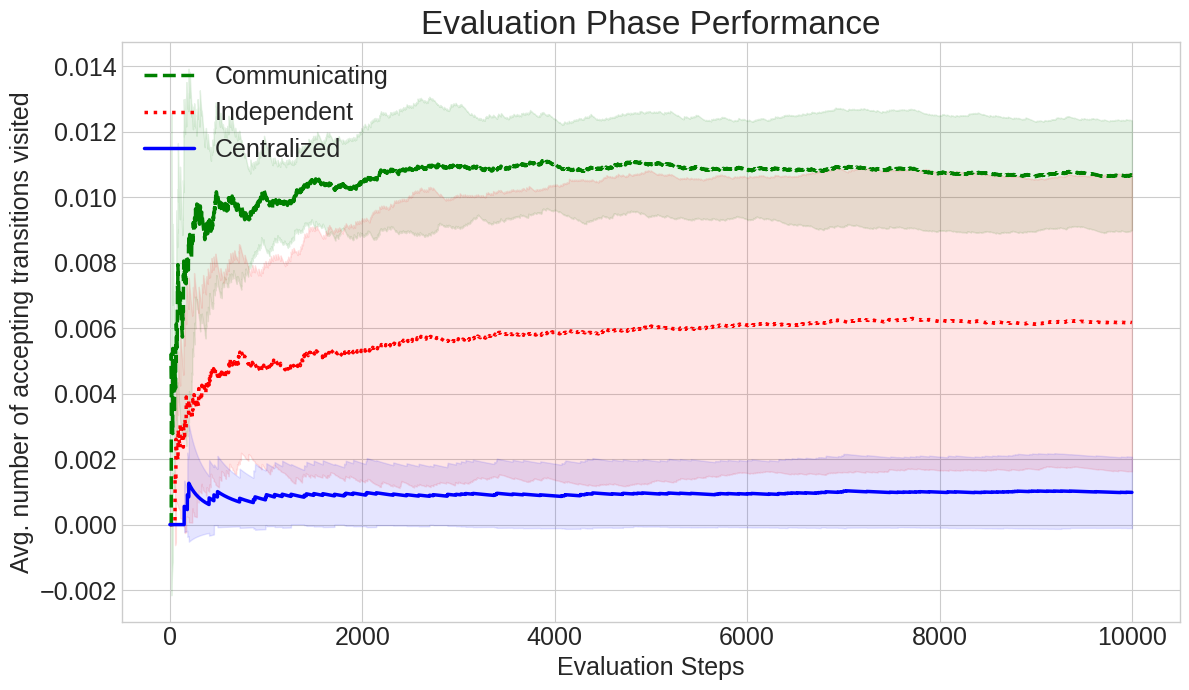

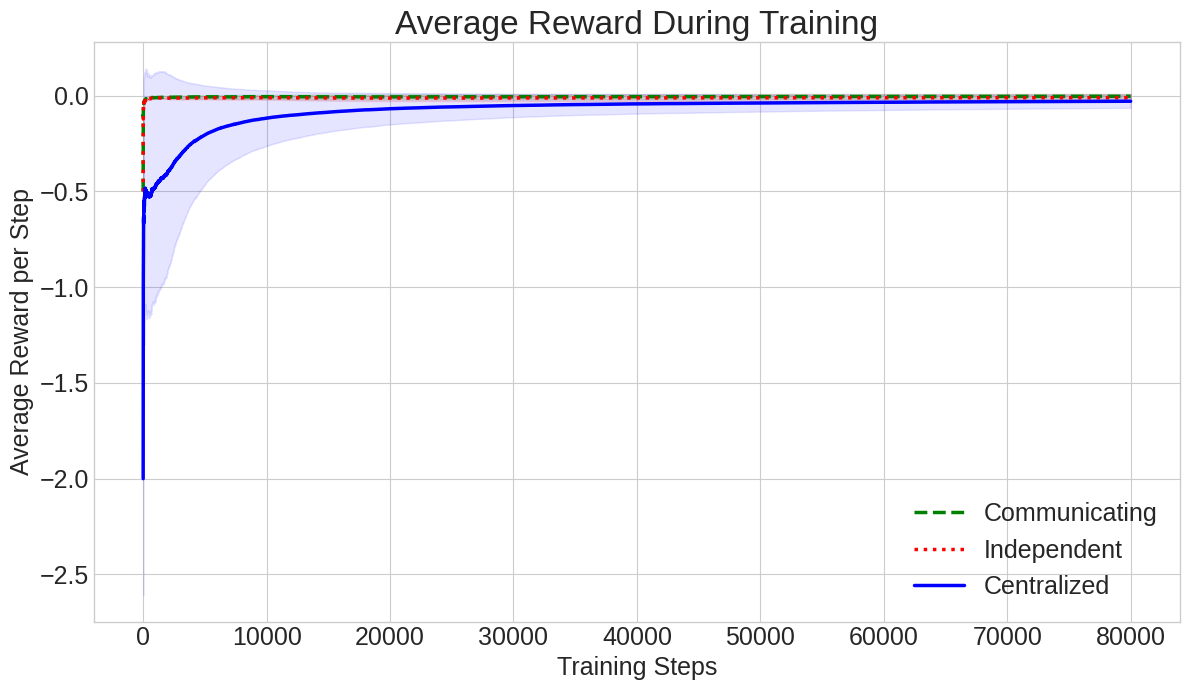

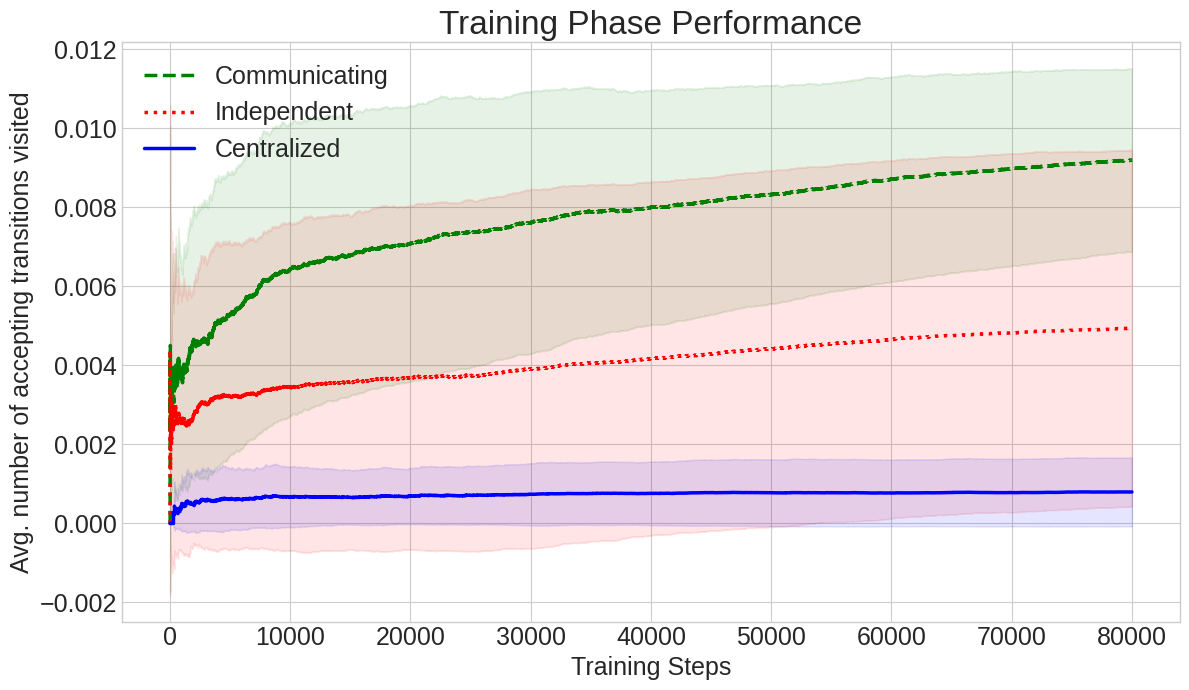

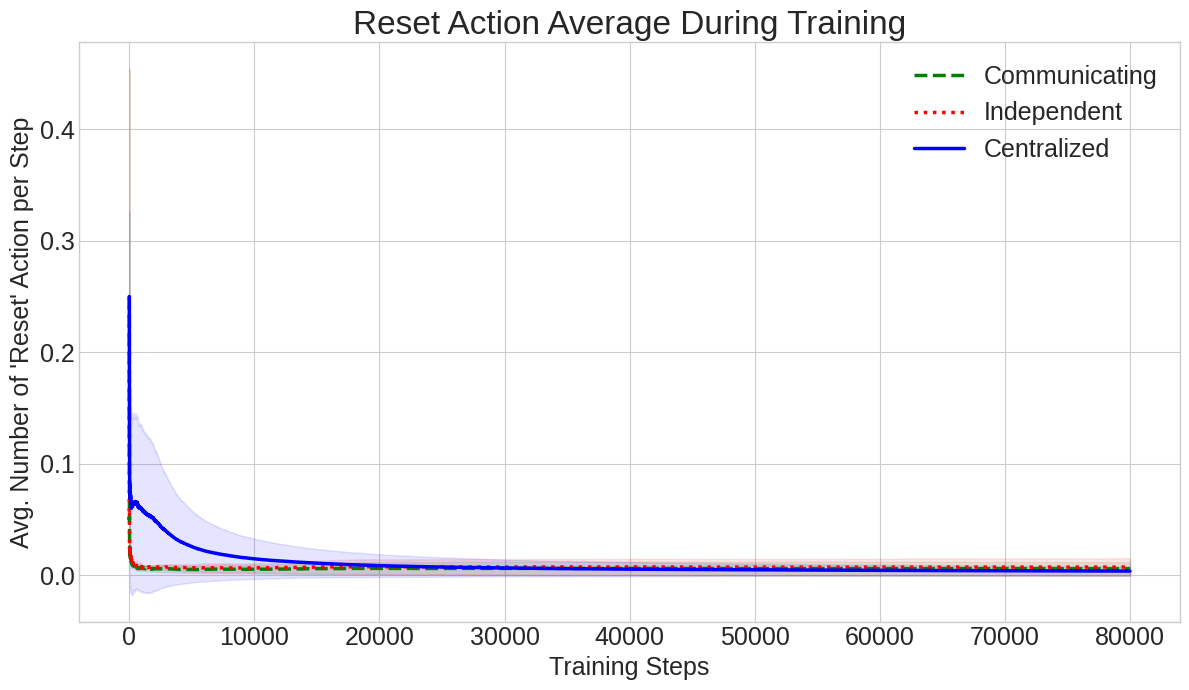


--- Generating Stepsize Comparison Plot ---


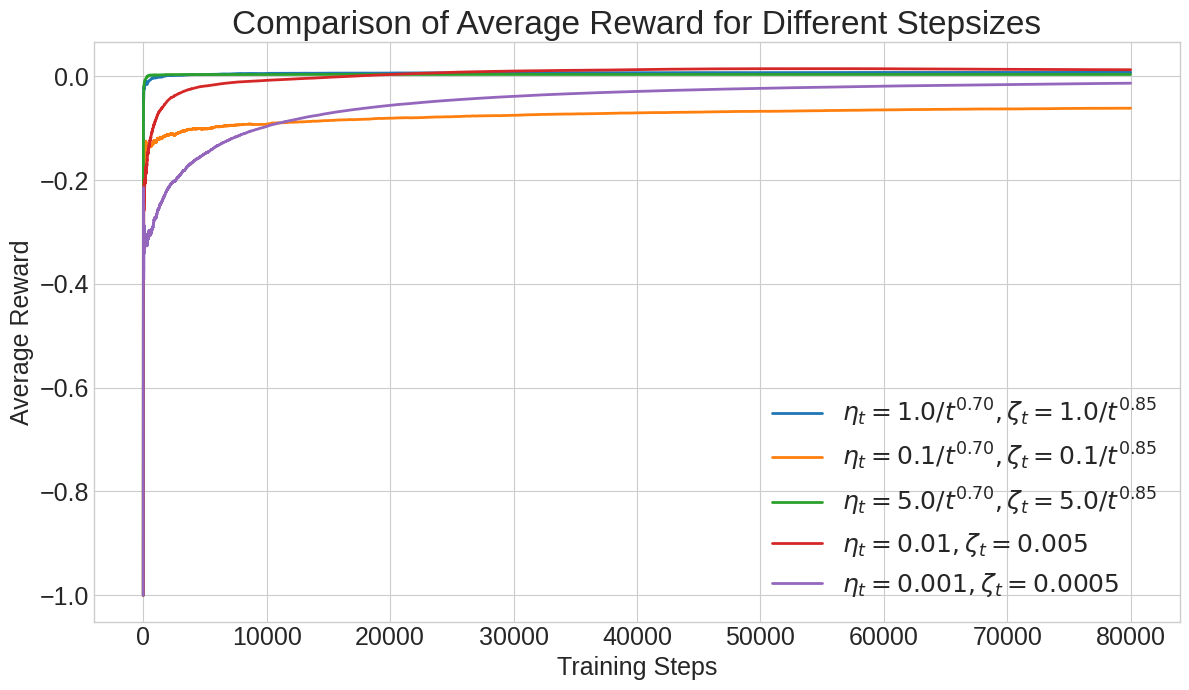



--- Final Evaluation Summary (Mean ± Std Dev over {NUM_SEEDS} seeds) ---
-----------------------------------------------------------------
| Mode            | Mean Total Satisfactions  | Std Dev         |
|-----------------|---------------------------|-----------------|
| Communicating   | 426.67                    | 66.82           |
| Independent     | 246.67                    | 181.67          |
| Centralized     | 39.33                     | 43.52           |
-----------------------------------------------------------------


In [ ]:
# @title
# code2 for visualizations

ALL_SEEDS = [5, 20, 24]
ALL_MODES = ['communicating', 'independent', 'centralized']

STEPSIZE_COMPARISON_SEED = 20
NUM_SEEDS = len(ALL_SEEDS)


import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random
import math

try:
    import pettingzoo
    from pettingzoo.utils import parallel_to_aec, aec_to_parallel
    from pettingzoo.test import parallel_api_test
    import pygame
    from gymnasium import spaces
    from IPython.display import display, Image
    import imageio
    import os
    os.environ["SDL_VIDEODRIVER"] = "dummy"
except ImportError:
    print("Installing PettingZoo, Pygame, and imageio...")
    # The following line is for Colab/Jupyter environments
    !pip install pettingzoo[classic] pygame imageio gymnasium > /dev/null 2>&1
    import pettingzoo
    from pettingzoo.utils import parallel_to_aec, aec_to_parallel
    from pettingzoo.test import parallel_api_test
    import pygame
    from gymnasium import spaces
    from IPython.display import display, Image
    import imageio
    import os
    os.environ["SDL_VIDEODRIVER"] = "dummy"
    print("Installation complete.")

# -----------------------------
# Grid World Configuration & Helper Functions
# -----------------------------
NUM_AGENTS = 4
GRID_ROWS = 6
GRID_COLS = 6
NUM_CELLS = GRID_ROWS * GRID_COLS

AGENT_ACTIONS = {'UP': 0, 'DOWN': 1, 'LEFT': 2, 'RIGHT': 3, 'STAY': 4, 'RESET_RM_STAY': 5}
NUM_ACTIONS_PER_AGENT = len(AGENT_ACTIONS)
ACTION_EFFECTS = {
    AGENT_ACTIONS['UP']: (-1, 0), AGENT_ACTIONS['DOWN']: (1, 0),
    AGENT_ACTIONS['LEFT']: (0, -1), AGENT_ACTIONS['RIGHT']: (0, 1),
    AGENT_ACTIONS['STAY']: (0, 0),
    AGENT_ACTIONS['RESET_RM_STAY']: (0, 0)
}
NUM_JOINT_ACTIONS = NUM_ACTIONS_PER_AGENT ** NUM_AGENTS

def get_flat_pos(row, col): return row * GRID_COLS + col
def get_row_col(flat_pos): return flat_pos // GRID_COLS, flat_pos % GRID_COLS

START_POSITIONS_LIST = [21, 15, 14, 20]
AGENT_RCH1_CELLS = {0: 0, 1: 30, 2: 35, 3: 5}
AGENT_RCH2_CELLS = {0: 5, 1: 0, 2: 30, 3: 35}
SAFE_TARGET_CELLS = set(AGENT_RCH1_CELLS.values()) | set(AGENT_RCH2_CELLS.values())

def get_manhattan_distance(pos1_flat, pos2_flat):
    r1, c1 = get_row_col(pos1_flat)
    r2, c2 = get_row_col(pos2_flat)
    return abs(r1 - r2) + abs(c1 - c2)

def decode_env_state(env_state_idx):
    positions = []; temp_idx = env_state_idx
    for _ in range(NUM_AGENTS):
        positions.append(temp_idx % NUM_CELLS); temp_idx //= NUM_CELLS
    return positions[::-1]

def encode_env_state(positions_list):
    env_state_idx = 0
    for pos in positions_list: env_state_idx = env_state_idx * NUM_CELLS + pos
    return env_state_idx

def decode_joint_action(joint_action_idx):
    actions = []; temp_idx = joint_action_idx
    for _ in range(NUM_AGENTS):
        actions.append(temp_idx % NUM_ACTIONS_PER_AGENT); temp_idx //= NUM_ACTIONS_PER_AGENT
    return actions[::-1]

def get_next_cell_pos(current_flat_pos, action_idx):
    r_curr, c_curr = get_row_col(current_flat_pos)
    dr, dc = ACTION_EFFECTS.get(action_idx, (0, 0))
    r_next, c_next = r_curr + dr, c_curr + dc
    if not (0 <= r_next < GRID_ROWS and 0 <= c_next < GRID_COLS):
        return current_flat_pos
    return get_flat_pos(r_next, c_next)

def get_non_colliding_initial_state():
    return encode_env_state(START_POSITIONS_LIST)

# -----------------------------
# State Feature Engineering (Needed for Eval)
# -----------------------------
RM_STATES = None
RM_STATE_MAP = None
NUM_RM_STATES = None

def get_state_features(env_state_idx, agent_index, rm_state):
    all_positions = decode_env_state(env_state_idx)
    my_pos = all_positions[agent_index]
    other_positions = [pos for i, pos in enumerate(all_positions) if i != agent_index]
    features = []
    my_r, my_c = get_row_col(my_pos)
    max_dist = (GRID_ROWS - 1) + (GRID_COLS - 1)
    features.extend([my_r / (GRID_ROWS - 1), my_c / (GRID_COLS - 1)])
    for pos_flat in other_positions:
        r, c = get_row_col(pos_flat)
        features.extend([r / (GRID_ROWS - 1), c / (GRID_COLS - 1)])
    dist_to_rch1 = get_manhattan_distance(my_pos, AGENT_RCH1_CELLS[agent_index])
    dist_to_rch2 = get_manhattan_distance(my_pos, AGENT_RCH2_CELLS[agent_index])
    features.append(dist_to_rch1 / max_dist if max_dist > 0 else 0)
    features.append(dist_to_rch2 / max_dist if max_dist > 0 else 0)
    for other_pos in other_positions:
        dist_to_other = get_manhattan_distance(my_pos, other_pos)
        features.append(dist_to_other / max_dist if max_dist > 0 else 0)
    is_on_edge = (my_r == 0 or my_r == GRID_ROWS - 1 or my_c == 0 or my_c == GRID_COLS - 1)
    is_in_corner = ((my_r == 0 or my_r == GRID_ROWS - 1) and (my_c == 0 or my_c == GRID_COLS - 1))
    features.extend([1.0 if is_on_edge else 0.0, 1.0 if is_in_corner else 0.0])
    rm_state_one_hot = np.zeros(NUM_RM_STATES)
    if rm_state in RM_STATE_MAP:
        rm_state_one_hot[RM_STATE_MAP[rm_state]] = 1.0
    features.extend(rm_state_one_hot)
    features.append(1.0) # Bias term
    return np.array(features)

def get_state_features_central(env_state_idx, rm_states_list):
    all_positions = decode_env_state(env_state_idx)
    features = []
    max_dist = (GRID_ROWS - 1) + (GRID_COLS - 1)
    for pos_flat in all_positions:
        r, c = get_row_col(pos_flat)
        features.extend([r / (GRID_ROWS - 1), c / (GRID_COLS - 1)])
    for i, pos_flat in enumerate(all_positions):
        dist_to_rch1 = get_manhattan_distance(pos_flat, AGENT_RCH1_CELLS[i])
        dist_to_rch2 = get_manhattan_distance(pos_flat, AGENT_RCH2_CELLS[i])
        features.append(dist_to_rch1 / max_dist if max_dist > 0 else 0)
        features.append(dist_to_rch2 / max_dist if max_dist > 0 else 0)
    for rm_state in rm_states_list:
        rm_state_one_hot = np.zeros(NUM_RM_STATES)
        if rm_state in RM_STATE_MAP:
            rm_state_one_hot[RM_STATE_MAP[rm_state]] = 1.0
        features.extend(rm_state_one_hot)
    features.append(1.0)
    return np.array(features)

# -----------------------------
# Probabilistic Action & Collision (Needed for Eval)
# -----------------------------
PROBABILISTIC_ACTION_CONFIG = {
    AGENT_ACTIONS['UP']: [(AGENT_ACTIONS['UP'], 0.8), (AGENT_ACTIONS['LEFT'], 0.1), (AGENT_ACTIONS['RIGHT'], 0.1)],
    AGENT_ACTIONS['DOWN']: [(AGENT_ACTIONS['DOWN'], 0.8), (AGENT_ACTIONS['LEFT'], 0.1), (AGENT_ACTIONS['RIGHT'], 0.1)],
    AGENT_ACTIONS['LEFT']: [(AGENT_ACTIONS['LEFT'], 0.8), (AGENT_ACTIONS['UP'], 0.1), (AGENT_ACTIONS['DOWN'], 0.1)],
    AGENT_ACTIONS['RIGHT']: [(AGENT_ACTIONS['RIGHT'], 0.8), (AGENT_ACTIONS['UP'], 0.1), (AGENT_ACTIONS['DOWN'], 0.1)],
    AGENT_ACTIONS['STAY']: [(AGENT_ACTIONS['STAY'], 1.0)],
    AGENT_ACTIONS['RESET_RM_STAY']: [(AGENT_ACTIONS['RESET_RM_STAY'], 1.0)]
}
def get_probabilistic_outcomes(action_idx): return PROBABILISTIC_ACTION_CONFIG.get(action_idx, [(action_idx, 1.0)])
def _calculate_next_state_with_collision_avoidance(current_s_idx, actual_actions):
    current_positions = decode_env_state(current_s_idx)
    potential_next_positions = [get_next_cell_pos(current_positions[i], actual_actions[i]) for i in range(NUM_AGENTS)]
    final_positions = list(current_positions); agent_indices = list(range(NUM_AGENTS)); colliding_agents = set()
    for i in agent_indices:
        if i in colliding_agents: continue
        for j in range(i + 1, NUM_AGENTS):
            if j in colliding_agents: continue
            if potential_next_positions[i] == potential_next_positions[j]:
                destination_cell = potential_next_positions[i]
                if destination_cell not in SAFE_TARGET_CELLS:
                    colliding_agents.add(i); colliding_agents.add(j)
    for i in agent_indices:
        if i not in colliding_agents:
            final_positions[i] = potential_next_positions[i]
    return encode_env_state(final_positions)

def get_label(env_state_idx, agent_index):
    positions = decode_env_state(env_state_idx)
    is_rch1 = (positions[agent_index] == AGENT_RCH1_CELLS[agent_index])
    is_rch2 = (positions[agent_index] == AGENT_RCH2_CELLS[agent_index])
    rch1_str = "(rch1)" if is_rch1 else "(!rch1)"
    rch2_str = "(rch2)" if is_rch2 else "(!rch2)"
    return f"{rch1_str}&{rch2_str}"

# -----------------------------
# Reward Machine & RL Components
# -----------------------------
class RewardMachine:
    def __init__(self, initial_state, states, transitions):
        self.initial_state = initial_state
        self.states = states
        self.transitions = {key: (value[0][0], int(value[0][1])) for key, value in transitions.items()}
    def step(self, current_rm_state, symbol):
        return self.transitions.get((current_rm_state, symbol), (current_rm_state, 0.0))

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# -----------------------------
# PettingZoo Environment
# -----------------------------
class GridWorldEnv(pettingzoo.ParallelEnv):
    metadata = {"render_modes": ["rgb_array"], "name": "gridworld-v0"}
    def __init__(self, render_mode="rgb_array"):
        self.agents = [f"agent_{i+1}" for i in range(NUM_AGENTS)]
        self.possible_agents = self.agents[:]; self.render_mode = render_mode
        self.num_env_states = NUM_CELLS ** NUM_AGENTS; self.current_env_state = 0
        self.observation_space = {a: spaces.Discrete(self.num_env_states) for a in self.agents}
        self.action_space = {a: spaces.Discrete(NUM_ACTIONS_PER_AGENT) for a in self.agents}
        self.screen_width, self.screen_height, self.screen = 400, 400, None
        colors = [plt.cm.viridis(i/max(1, NUM_AGENTS-1)) for i in range(NUM_AGENTS)]
        self.agent_colors = [(int(r*255), int(g*255), int(b*255)) for r,g,b,a in colors]
    def reset(self, seed=None, options=None):
        if seed is not None: np.random.seed(seed); random.seed(seed)
        self.current_env_state = get_non_colliding_initial_state()
        return self._get_obs(), {a: {} for a in self.agents}
    def _get_obs(self): return {a: self.current_env_state for a in self.agents}
    def step(self, actions):
        actual_actions = []
        for i, agent_id in enumerate(self.agents):
            policy_action = actions[agent_id]
            outcomes = get_probabilistic_outcomes(policy_action)
            action_choices, probs = zip(*outcomes)
            actual_actions.append(np.random.choice(action_choices, p=probs))
        self.current_env_state = _calculate_next_state_with_collision_avoidance(
            self.current_env_state, actual_actions
        )
        return self._get_obs(),{a:0 for a in self.agents},{a:False for a in self.agents},{a:False for a in self.agents},{a:{} for a in self.agents}
    def render(self):
        if self.screen is None: pygame.init(); self.screen = pygame.Surface((self.screen_width, self.screen_height))
        cell_w, cell_h = self.screen_width/GRID_COLS, self.screen_height/GRID_ROWS
        self.screen.fill((255, 255, 255))
        indicator_w = cell_w / 2; indicator_h = cell_h / 2
        quadrant_offsets = [(0, 0), (indicator_w, 0), (0, indicator_h), (indicator_w, indicator_h)]
        for i in range(NUM_AGENTS):
            agent_color = self.agent_colors[i]; offset_x, offset_y = quadrant_offsets[i]
            rch1_flat = AGENT_RCH1_CELLS[i]; r1, c1 = get_row_col(rch1_flat)
            rch1_color = (min(255, agent_color[0] + 120), min(255, agent_color[1] + 120), min(255, agent_color[2] + 120))
            indicator_x1 = c1 * cell_w + offset_x; indicator_y1 = r1 * cell_h + offset_y
            pygame.draw.rect(self.screen, rch1_color, (indicator_x1, indicator_y1, indicator_w, indicator_h))
            rch2_flat = AGENT_RCH2_CELLS[i]; r2, c2 = get_row_col(rch2_flat); rch2_color = agent_color
            indicator_x2 = c2 * cell_w + offset_x; indicator_y2 = r2 * cell_h + offset_y
            pygame.draw.rect(self.screen, rch2_color, (indicator_x2, indicator_y2, indicator_w, indicator_h))
        for r in range(GRID_ROWS):
            for c in range(GRID_COLS): pygame.draw.rect(self.screen, (128,128,128), (c*cell_w, r*cell_h, cell_w, cell_h), 1)
        for i, pos_flat in enumerate(decode_env_state(self.current_env_state)):
            r,c = get_row_col(pos_flat)
            pygame.draw.circle(self.screen, self.agent_colors[i], (c*cell_w+cell_w/2, r*cell_h+cell_h/2), min(cell_w, cell_h)/3)
        if self.render_mode == "rgb_array": return np.transpose(np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2))
    def close(self):
        if self.screen: pygame.quit(); self.screen = None

# =================================================================
# SECTION 2: LOAD DATA AND RUN VISUALIZATIONS
# =================================================================
def visualize():
    global RM_STATES, RM_STATE_MAP, NUM_RM_STATES # Declare as global to modify
    num_agents = NUM_AGENTS

    results_by_mode = {
        mode: {
            'training_rewards': [],
            'training_satisfactions': [],
            'reset_action_counts': [],
            'eval_satisfactions': []
        } for mode in ALL_MODES
    }

    steps_history = None
    eval_steps_history = None

    last_run_results = None
    last_run_eval_frames = []

    last_run_mode = ALL_MODES[-1]
    last_run_seed_index = NUM_SEEDS

    for mode in ALL_MODES:
        for i, seed in enumerate(ALL_SEEDS):
            seed_index = i + 1
            print(f"\n--- Loading and Processing for MODE: {mode.upper()}, SEED {seed_index} ---")

            # --- Load Saved Data (using actual seed) ---
            try:
                results_file = f'training_results_{mode}_seed_{seed}.npz'
                rm_file = f'reward_machine_{mode}_seed_{seed}.pkl'
                results = np.load(results_file, allow_pickle=True)
                with open(rm_file, 'rb') as f:
                    rm = pickle.load(f)
            except FileNotFoundError:
                print(f"Error: '{results_file}' or '{rm_file}' not found.")
                print("Please run Code 1 first to generate these files.")
                return
            except Exception as e:
                print(f"Error loading files for mode {mode}, seed {seed}: {e}")
                return

            # --- Extract Loaded Training Data ---
            results_by_mode[mode]['training_rewards'].append(results['overall_average_reward_history'])
            results_by_mode[mode]['training_satisfactions'].append(results['successful_satisfactions_history'])
            results_by_mode[mode]['reset_action_counts'].append(results['reset_action_counts_history'])

            if steps_history is None: # Grab x-axis from the first run
                steps_history = results['steps_history']

            RM_STATES = sorted(list(rm.states))
            RM_STATE_MAP = {state: i for i, state in enumerate(RM_STATES)}
            NUM_RM_STATES = len(RM_STATES)

            print(f"  [Evaluation] Running evaluation for Mode {mode.upper()}, SEED {seed_index}...")
            num_evaluation_steps = 10000; env = GridWorldEnv()
            obs, _ = env.reset(seed=seed + 1)

            evaluation_frames = []
            num_eval_animation_steps = 1000
            eval_satisfactions = 0
            current_eval_steps_history, current_eval_satisfactions_history = [], []
            evaluation_temperature = 0.9

            actor_weights = results['actor_weights']

            # --- Centralized Evaluation ---
            if mode == 'centralized':
                eval_rm_states = [rm.initial_state for _ in range(num_agents)]
                # actor_weights is a single array
                for step in range(num_evaluation_steps):
                    if seed_index == last_run_seed_index and mode == last_run_mode and step < num_eval_animation_steps:
                        evaluation_frames.append(env.render())

                    current_s_idx = obs["agent_1"]
                    features = get_state_features_central(current_s_idx, eval_rm_states)
                    logits = np.dot(features, actor_weights)
                    temp_adjusted_logits = logits / evaluation_temperature
                    action_probabilities = softmax(temp_adjusted_logits)
                    joint_action_idx = np.random.choice(NUM_JOINT_ACTIONS, p=action_probabilities)
                    actions_list = decode_joint_action(joint_action_idx)
                    actions_dict = {f"agent_{i_agent+1}": actions_list[i_agent] for i_agent in range(num_agents)}

                    obs, _, _, _, _ = env.step(actions_dict)
                    next_s_idx = obs["agent_1"]
                    labels = [get_label(next_s_idx, i_agent) for i_agent in range(num_agents)]
                    temp_next_rm_states = list(eval_rm_states)
                    for i_agent in range(num_agents):
                        if actions_dict[f"agent_{i_agent+1}"] == AGENT_ACTIONS['RESET_RM_STAY']:
                            temp_next_rm_states[i_agent] = rm.initial_state
                        else:
                            next_rm, r = rm.step(eval_rm_states[i_agent], labels[i_agent])
                            temp_next_rm_states[i_agent] = next_rm
                            if r > 0: eval_satisfactions += 1
                    eval_rm_states = temp_next_rm_states
                    current_eval_steps_history.append(step); current_eval_satisfactions_history.append(eval_satisfactions)

            # --- Decentralized Evaluation ---
            else: # 'communicating' or 'independent'
                eval_rm_states = [rm.initial_state for _ in range(num_agents)]
                # actor_weights is a list of arrays
                for step in range(num_evaluation_steps):
                    if seed_index == last_run_seed_index and mode == last_run_mode and step < num_eval_animation_steps:
                        evaluation_frames.append(env.render())

                    actions_dict = {}
                    current_s_idx = obs["agent_1"]
                    for i_agent in range(num_agents):
                        agent_id_str = f"agent_{i_agent+1}"
                        features = get_state_features(current_s_idx, i_agent, eval_rm_states[i_agent])
                        logits = np.dot(features, actor_weights[i_agent])
                        temp_adjusted_logits = logits / evaluation_temperature
                        action_probabilities = softmax(temp_adjusted_logits)
                        actions_dict[agent_id_str] = np.random.choice(NUM_ACTIONS_PER_AGENT, p=action_probabilities)

                    obs, _, _, _, _ = env.step(actions_dict)
                    next_s_idx = obs["agent_1"]
                    labels = [get_label(next_s_idx, i_agent) for i_agent in range(num_agents)]
                    temp_next_rm_states = list(eval_rm_states)
                    for i_agent in range(num_agents):
                        agent_id_str = f"agent_{i_agent+1}"
                        if actions_dict[agent_id_str] == AGENT_ACTIONS['RESET_RM_STAY']:
                            temp_next_rm_states[i_agent] = rm.initial_state
                        else:
                            next_rm, r = rm.step(eval_rm_states[i_agent], labels[i_agent])
                            temp_next_rm_states[i_agent] = next_rm
                            if r > 0: eval_satisfactions += 1
                    eval_rm_states = temp_next_rm_states
                    current_eval_steps_history.append(step); current_eval_satisfactions_history.append(eval_satisfactions)

            env.close()

            # --- Store this seed's evaluation results ---
            results_by_mode[mode]['eval_satisfactions'].append(current_eval_satisfactions_history)
            if eval_steps_history is None: # Grab x-axis
                eval_steps_history = current_eval_steps_history

            print(f"  [Evaluation] Mode {mode.upper()}, SEED {seed_index} complete. Total Satisfactions: {eval_satisfactions}")

            # --- Store last run's data for animations/policy plots ---
            if seed_index == last_run_seed_index and mode == last_run_mode:
                last_run_results = results
                last_run_eval_frames = evaluation_frames

    print("\n--- All seeds and modes processed. Calculating statistics. ---")

    stats_by_mode = {}

    # Create step count arrays (e.g., [1, 2, 3, ...]) to avoid division by zero
    step_counts_train = np.array(steps_history) + 1
    step_counts_eval = np.array(eval_steps_history) + 1

    for mode in ALL_MODES:
        # --- Training Rewards ---
        all_tr_rewards_np = np.array(results_by_mode[mode]['training_rewards'])
        mean_tr_reward = np.mean(all_tr_rewards_np, axis=0)
        std_tr_reward = np.std(all_tr_rewards_np, axis=0)

        # --- Training Satisfactions ---
        all_tr_satis_np = np.array(results_by_mode[mode]['training_satisfactions'])
        all_tr_satis_rate_np = all_tr_satis_np / step_counts_train / num_agents
        mean_tr_satis_rate = np.mean(all_tr_satis_rate_np, axis=0)
        std_tr_satis_rate = np.std(all_tr_satis_rate_np, axis=0)

        # --- Evaluation Satisfactions ---
        all_eval_satis_np = np.array(results_by_mode[mode]['eval_satisfactions'])
        all_eval_satis_rate_np = all_eval_satis_np / step_counts_eval / num_agents
        mean_eval_satis_rate = np.mean(all_eval_satis_rate_np, axis=0)
        std_eval_satis_rate = np.std(all_eval_satis_rate_np, axis=0)

        # --- Reset Action ---
        all_reset_counts_np = np.array(results_by_mode[mode]['reset_action_counts'])
        all_reset_rate_np = all_reset_counts_np / step_counts_train / num_agents
        mean_reset_rate = np.mean(all_reset_rate_np, axis=0)
        std_reset_rate = np.std(all_reset_rate_np, axis=0)

        # Store final (non-rate) satisfaction count for summary
        final_eval_satisfactions = [run[-1] for run in all_eval_satis_np]
        mean_final_eval_satis = np.mean(final_eval_satisfactions)
        std_final_eval_satis = np.std(final_eval_satisfactions)

        stats_by_mode[mode] = {
            'mean_tr_reward': mean_tr_reward,
            'std_tr_reward': std_tr_reward,
            'mean_tr_satis_rate': mean_tr_satis_rate,
            'std_tr_satis_rate': std_tr_satis_rate,
            'mean_eval_satis_rate': mean_eval_satis_rate,
            'std_eval_satis_rate': std_eval_satis_rate,
            'mean_reset_rate': mean_reset_rate,
            'std_reset_rate': std_reset_rate,
            'mean_final_eval_satis': mean_final_eval_satis,
            'std_final_eval_satis': std_final_eval_satis
        }

    # --- Save Animations (from last run only) ---
    print(f"\n--- Saving animations from LAST run (Mode: {last_run_mode.upper()}, SEED {last_run_seed_index}) ---")
    try:
        if 'training_frames' in last_run_results and last_run_results['training_frames'].size > 0:
            print("  Saving training_animation.gif...")
            imageio.mimsave('training_animation.gif', last_run_results['training_frames'], fps=20)

        if last_run_eval_frames:
            print("  Saving trained_agent_animation.gif...")
            imageio.mimsave('trained_agent_animation.gif', last_run_eval_frames, fps=30)
    except Exception as e:
        print(f"Error saving animations: {e}")


    print("\n--- Generating Baseline Comparison Plots ---")
    plt.style.use('seaborn-v0_8-whitegrid')

    # --- Font Size Configuration ---
    FONTSIZE_TITLE = 24
    FONTSIZE_LABEL = 18
    FONTSIZE_LEGEND = 18
    FONTSIZE_TICKS = 18

    colors = {'communicating': 'green', 'independent': 'red', 'centralized': 'blue'}
    linestyles = {'communicating': '--', 'independent': ':', 'centralized': '-'}
    linewidths = {'communicating': 2.5, 'independent': 2.5, 'centralized': 2.5}

    # --- Plot 1: Evaluation ---
    plt.figure(figsize=(12, 7))
    for mode in ALL_MODES:
        stats = stats_by_mode[mode]
        plt.plot(eval_steps_history, stats['mean_eval_satis_rate'],
                 label=f'{mode.capitalize()}',
                 color=colors[mode],
                 linestyle=linestyles[mode],
                 linewidth=linewidths[mode])
        plt.fill_between(eval_steps_history,
                         stats['mean_eval_satis_rate'] - stats['std_eval_satis_rate'],
                         stats['mean_eval_satis_rate'] + stats['std_eval_satis_rate'],
                         color=colors[mode], alpha=0.1)

    plt.title(f"Evaluation Phase Performance", fontsize=FONTSIZE_TITLE)
    plt.xlabel("Evaluation Steps", fontsize=FONTSIZE_LABEL)
    plt.ylabel("Avg. number of accepting transitions visited", fontsize=FONTSIZE_LABEL)
    plt.xticks(fontsize=FONTSIZE_TICKS); plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.legend(fontsize=FONTSIZE_LEGEND); plt.tight_layout()
    plt.savefig("plot_evaluation_performance_RATE_COMPARISON.png"); plt.show()


    # --- Plot 2: Training Average Reward ---
    plt.figure(figsize=(12, 7))
    for mode in ALL_MODES:
        stats = stats_by_mode[mode]
        plt.plot(steps_history, stats['mean_tr_reward'],
                 label=f'{mode.capitalize()}',
                 color=colors[mode],
                 linestyle=linestyles[mode],
                 linewidth=linewidths[mode])
        plt.fill_between(steps_history,
                         stats['mean_tr_reward'] - stats['std_tr_reward'],
                         stats['mean_tr_reward'] + stats['std_tr_reward'],
                         color=colors[mode], alpha=0.1)

    plt.title(f"Average Reward During Training", fontsize=FONTSIZE_TITLE)
    plt.xlabel("Training Steps", fontsize=FONTSIZE_LABEL); plt.ylabel("Average Reward per Step", fontsize=FONTSIZE_LABEL)
    plt.xticks(fontsize=FONTSIZE_TICKS); plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.legend(fontsize=FONTSIZE_LEGEND); plt.tight_layout()
    plt.savefig("plot_training_reward_COMPARISON.png"); plt.show()

    # --- Plot 3: Training ---
    plt.figure(figsize=(12, 7))
    for mode in ALL_MODES:
        stats = stats_by_mode[mode]
        plt.plot(steps_history, stats['mean_tr_satis_rate'],
                 label=f'{mode.capitalize()}',
                 color=colors[mode],
                 linestyle=linestyles[mode],
                 linewidth=linewidths[mode])
        plt.fill_between(steps_history,
                         stats['mean_tr_satis_rate'] - stats['std_tr_satis_rate'],
                         stats['mean_tr_satis_rate'] + stats['std_tr_satis_rate'],
                         color=colors[mode], alpha=0.1)

    plt.title(f"Training Phase Performance", fontsize=FONTSIZE_TITLE)
    plt.xlabel("Training Steps", fontsize=FONTSIZE_LABEL)
    plt.ylabel("Avg. number of accepting transitions visited", fontsize=FONTSIZE_LABEL)
    plt.xticks(fontsize=FONTSIZE_TICKS); plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.legend(fontsize=FONTSIZE_LEGEND); plt.tight_layout()
    plt.savefig("plot_training_satisfactions_RATE_COMPARISON.png"); plt.show()

    # --- Training Reset Action ---
    plt.figure(figsize=(12, 7))
    for mode in ALL_MODES:
        stats = stats_by_mode[mode]
        plt.plot(steps_history, stats['mean_reset_rate'],
                 label=f'{mode.capitalize()}',
                 color=colors[mode],
                 linestyle=linestyles[mode],
                 linewidth=linewidths[mode])
        plt.fill_between(steps_history,
                         stats['mean_reset_rate'] - stats['std_reset_rate'],
                         stats['mean_reset_rate'] + stats['std_reset_rate'],
                         color=colors[mode], alpha=0.1)

    plt.title(f"Reset Action Average During Training", fontsize=FONTSIZE_TITLE)
    plt.xlabel("Training Steps", fontsize=FONTSIZE_LABEL)
    plt.ylabel("Avg. Number of 'Reset' Action per Step", fontsize=FONTSIZE_LABEL)
    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.legend(fontsize=FONTSIZE_LEGEND); plt.tight_layout();
    plt.savefig("plot_training_reset_rate_COMPARISON.png"); plt.show()


    print("\n--- Generating Stepsize Comparison Plot ---")
    try:
        stepsize_results = np.load(f'stepsize_comparison_results_seed_{STEPSIZE_COMPARISON_SEED}.npz')


        legend_map = {
            "Variable (num=1, original)": "$\\eta_t=1.0/t^{0.70}, \\zeta_t=1.0/t^{0.85}$",
            "Variable (num=0.1)": "$\\eta_t=0.1/t^{0.70}, \\zeta_t=0.1/t^{0.85}$",
            "Variable (num=5)": "$\\eta_t=5.0/t^{0.70}, \\zeta_t=5.0/t^{0.85}$",
            "Constant (critic=0.01, actor=0.005)": "$\\eta_t=0.01, \\zeta_t=0.005$",
            "Constant (critic=0.001, actor=0.0005)": "$\\eta_t=0.001, \\zeta_t=0.0005$"
        }


        plt.figure(figsize=(12, 7))
        for name in stepsize_results.files:
            # Data is saved as a 2-element array: [steps_history, reward_history]
            data = stepsize_results[name]
            steps = data[0]
            rewards = data[1]


            label = legend_map.get(name, name)
            plt.plot(steps, rewards, label=label, linewidth=2)


        plt.title(f"Comparison of Average Reward for Different Stepsizes", fontsize=FONTSIZE_TITLE) # Title updated
        plt.xlabel("Training Steps", fontsize=FONTSIZE_LABEL)
        plt.ylabel("Average Reward", fontsize=FONTSIZE_LABEL)
        plt.xticks(fontsize=FONTSIZE_TICKS); plt.yticks(fontsize=FONTSIZE_TICKS)
        plt.legend(fontsize=FONTSIZE_LEGEND)
        plt.tight_layout()
        plt.savefig(f"plot_stepsize_comparison_seed_{STEPSIZE_COMPARISON_SEED}.png");
        plt.show()

    except FileNotFoundError:
        print(f"Could not find 'stepsize_comparison_results_seed_{STEPSIZE_COMPARISON_SEED}.npz'.")
        print("Skipping stepsize comparison plot. Run Code 1 to generate this file.")
    except Exception as e:
        print(f"Error plotting stepsize comparison: {e}")


    # --- Final Evaluation Summary Table ---
    print("\n\n--- Final Evaluation Summary (Mean ± Std Dev over {NUM_SEEDS} seeds) ---")
    print("-----------------------------------------------------------------")
    print(f"| {'Mode':<15} | {'Mean Total Satisfactions':<25} | {'Std Dev':<15} |")
    print("|-----------------|---------------------------|-----------------|")
    for mode in ALL_MODES:
        mean_val = stats_by_mode[mode]['mean_final_eval_satis']
        std_val = stats_by_mode[mode]['std_final_eval_satis']
        print(f"| {mode.capitalize():<15} | {mean_val:<25.2f} | {std_val:<15.2f} |")
    print("-----------------------------------------------------------------")


# --- Call the visualization function ---
visualize()